In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy, skew, kurtosis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

#### Load Data

In [30]:
path = "../data/raw/PS_20174392719_1491204439457_log.csv"
df = pd.read_csv(path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


#### Save Fraud Label for Validation

In [31]:
df_labels = df[['isFraud', 'isFlaggedFraud']].copy()
df_labels.to_parquet('../data/processed/real_used/labels_validation.parquet', index=False)
print(f"Fraud labels saved: {df_labels['isFraud'].sum():,} fraud cases out of {len(df):,} total")
print(f"Fraud rate: {df_labels['isFraud'].mean()*100:.4f}% (highly imbalanced)")

Fraud labels saved: 8,213 fraud cases out of 6,362,620 total
Fraud rate: 0.1291% (highly imbalanced)


Justification: The fraud label should not be used as a classification target, as mentioned in the project instructions. However, the data is retained for validation after mining is complete.

#### Data Quality Check

In [32]:
# Missing Value
miss = df.isnull().sum()
print("missing value : ", miss[miss > 0] if miss.sum() > 0 else 'Nothing missing value')

# Duplicated
duplicates = df.duplicated().sum()
print("duplicate rows : ", duplicates)

# Negative values
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
print("Negative value check : ")
for col in num_cols:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count} negatif", '(anomalies)' if neg_count>0 else '(valid)')

missing value :  Nothing missing value
duplicate rows :  0
Negative value check : 
amount: 0 negatif (valid)
oldbalanceOrg: 0 negatif (valid)
newbalanceOrig: 0 negatif (valid)
oldbalanceDest: 0 negatif (valid)
newbalanceDest: 0 negatif (valid)


#### Distribution Transaction Type

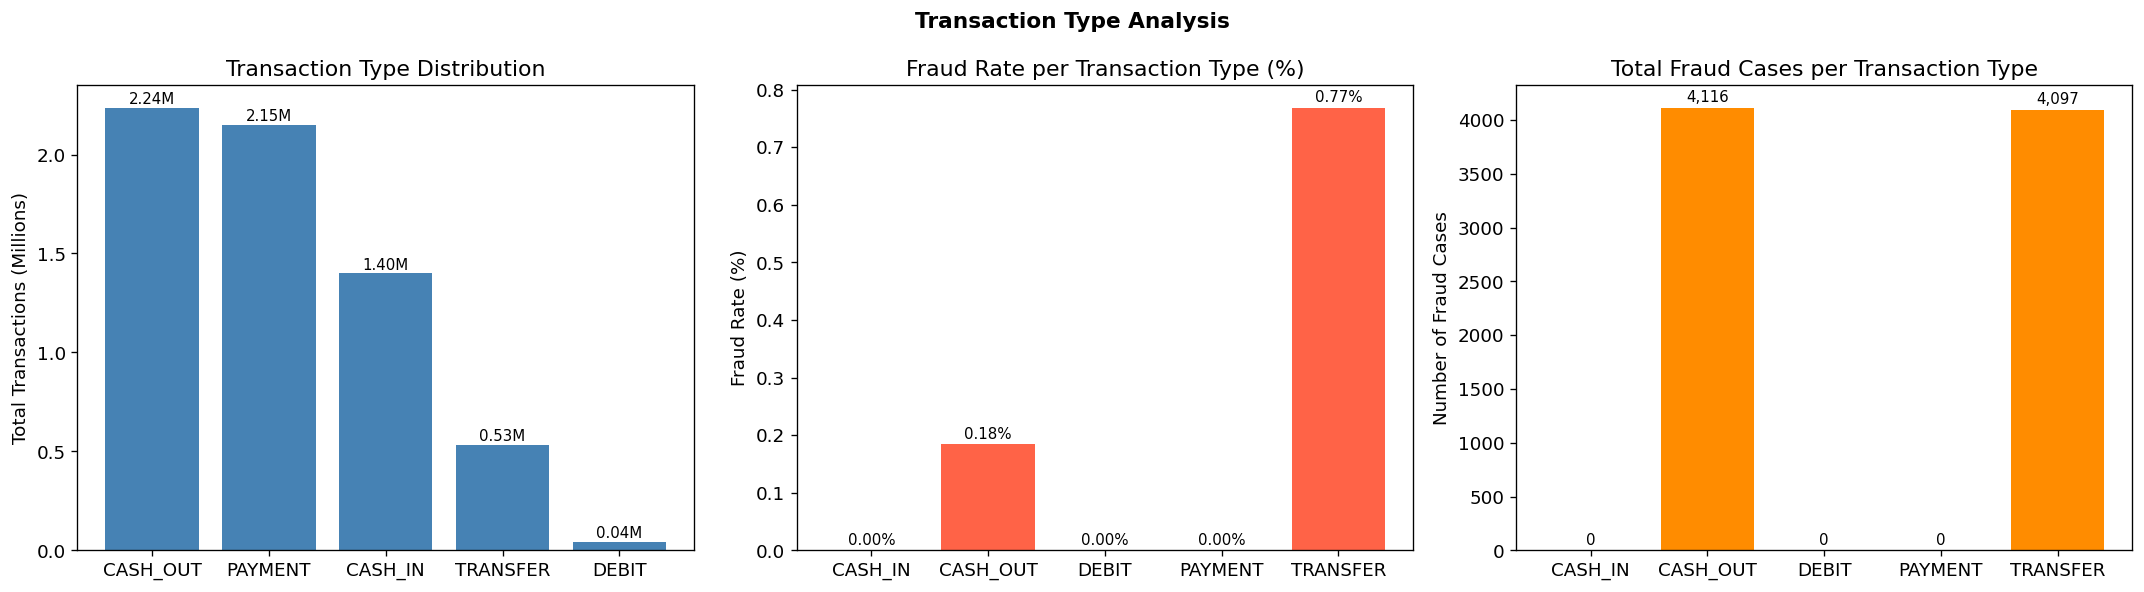

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3a. General Distribution
type_counts = df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values / 1e6, color='steelblue')
axes[0].set_title('Transaction Type Distribution')
axes[0].set_ylabel('Total Transactions (Millions)')
for i, (t, v) in enumerate(zip(type_counts.index, type_counts.values)):
    axes[0].text(i, v/1e6 + 0.02, f'{v/1e6:.2f}M', ha='center', fontsize=9)

# 3b. Fraud rate per type
fraud_by_type = df.groupby('type')['isFraud'].mean() * 100
axes[1].bar(fraud_by_type.index, fraud_by_type.values, color='tomato')
axes[1].set_title('Fraud Rate per Transaction Type (%)')
axes[1].set_ylabel('Fraud Rate (%)')
for i, (t, v) in enumerate(zip(fraud_by_type.index, fraud_by_type.values)):
    axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9)

# 3c. Absolute fraud count per type
fraud_count_by_type = df.groupby('type')['isFraud'].sum()
axes[2].bar(fraud_count_by_type.index, fraud_count_by_type.values, color='darkorange')
axes[2].set_title('Total Fraud Cases per Transaction Type')
axes[2].set_ylabel('Number of Fraud Cases')
for i, (t, v) in enumerate(zip(fraud_count_by_type.index, fraud_count_by_type.values)):
    axes[2].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Transaction Type Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('../outputs/eda_01_transaction_types.png', bbox_inches='tight')
plt.show()

Insight: Fraud only occurs via Cash Out and Transfer, aligning with the layering stage in money laundering practices. In this stage, fraudsters use rapid electronic transfers to obscure the illicit source of funds and subsequent cash-outs to completely break the digital audit trail.

#### Distribution Numeric Feature

In [36]:
desc = df[num_cols].describe(percentiles=[.01, .25, .5, .75, .95, .99])
print(desc.round(0))

           amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
count   6362620.0      6362620.0       6362620.0       6362620.0   
mean     179862.0       833883.0        855114.0       1100702.0   
std      603858.0      2888243.0       2924049.0       3399180.0   
min           0.0            0.0             0.0             0.0   
1%          449.0            0.0             0.0             0.0   
25%       13390.0            0.0             0.0             0.0   
50%       74872.0        14208.0             0.0        132706.0   
75%      208721.0       107315.0        144258.0        943037.0   
95%      518634.0      5823702.0       5980262.0       5147230.0   
99%     1615979.0     16027256.0      16176161.0      12371819.0   
max    92445517.0     59585040.0      49585040.0     356015889.0   

       newbalanceDest  
count       6362620.0  
mean        1224996.0  
std         3674129.0  
min               0.0  
1%                0.0  
25%               0.0  
50%          21


[Skewness & Kurtosis]
  amount: skew=30.99, kurtosis=1797.96 → Sangat right-skewed
  oldbalanceOrg: skew=5.25, kurtosis=32.96 → Sangat right-skewed
  newbalanceOrig: skew=5.18, kurtosis=32.07 → Sangat right-skewed
  oldbalanceDest: skew=19.92, kurtosis=948.67 → Sangat right-skewed
  newbalanceDest: skew=19.35, kurtosis=862.16 → Sangat right-skewed


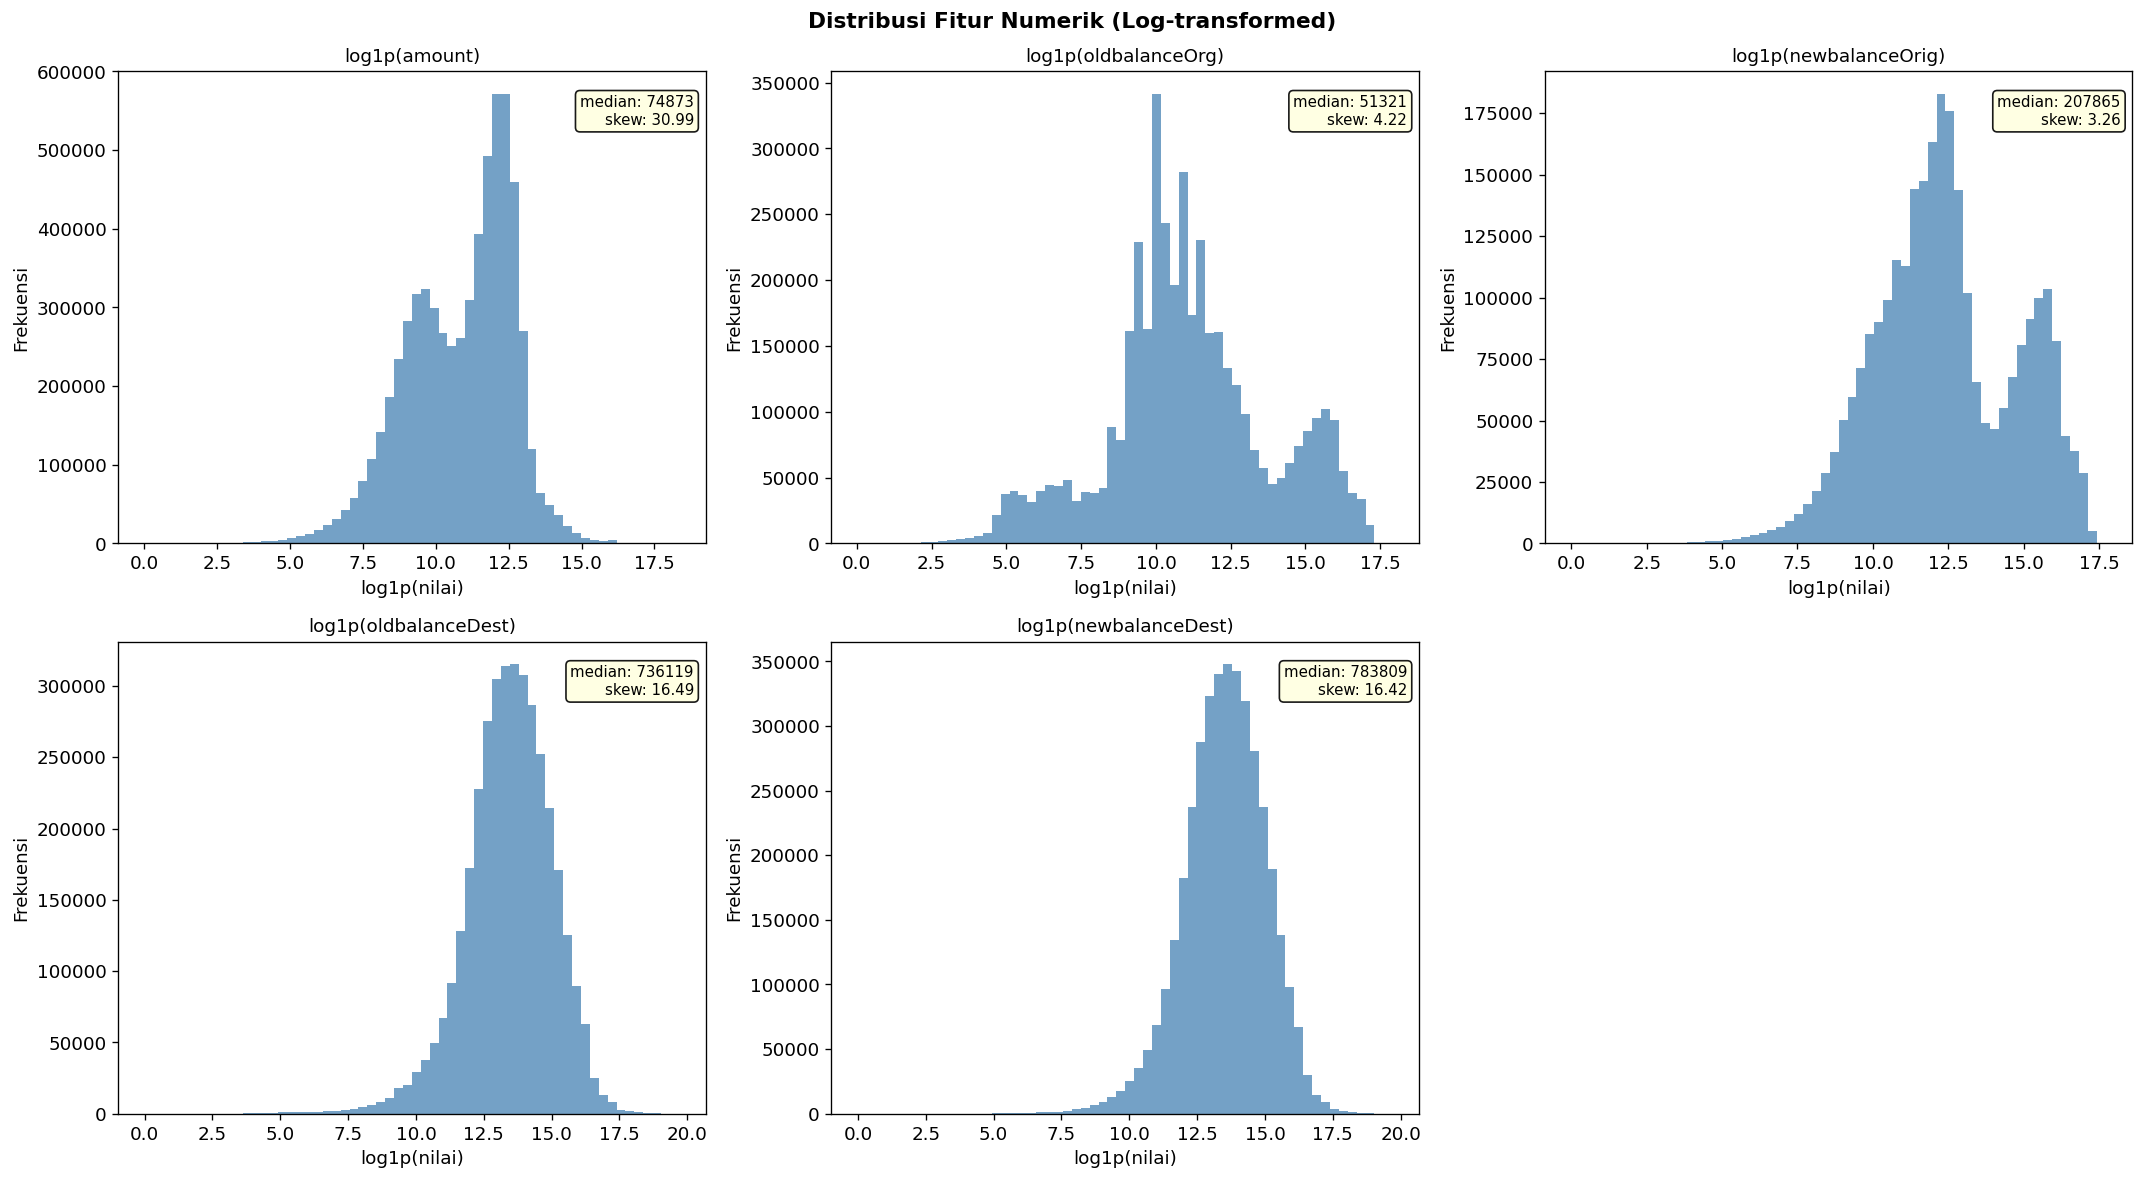

In [38]:
print("\n[Skewness & Kurtosis]")
for col in num_cols:
    s = skew(df[col].dropna())
    k = kurtosis(df[col].dropna())
    print(f"  {col}: skew={s:.2f}, kurtosis={k:.2f} → {'Sangat right-skewed' if s > 2 else 'Moderate'}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    data = df[col][df[col] > 0]
    log_data = np.log1p(data)
    axes[i].hist(log_data, bins=60, color='steelblue', alpha=0.75, edgecolor='none')
    axes[i].set_title(f'log1p({col})', fontsize=11)
    axes[i].set_xlabel('log1p(nilai)')
    axes[i].set_ylabel('Frekuensi')
    axes[i].text(0.98, 0.95,
        f"median: {data.median():.0f}\nskew: {skew(data):.2f}",
        transform=axes[i].transAxes, va='top', ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik (Log-transformed)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Justification using log1p :
We applied the log1p transformation during the EDA stage because the raw data exhibits high variance and contains extreme outliers, making visual analysis challenging. This logarithmic transformation serves to stabilize the variance and mitigate severe right-skewness. By normalizing the scale of the data distribution, hidden patterns—such as the bimodal distributions observed in the transaction amounts and sender balances—are clearly revealed, thereby providing deeper and more accurate insights into the dataset's characteristics.

Insight :
- The data exhibits extreme right-skewness, particularly prominent in the amount feature (skew: 30.99), followed by oldbalanceDest and newbalanceDest.
- A distinct bimodal distribution is observed in amount, oldbalanceOrg, and newbalanceOrig, clearly differentiating the transaction behaviors between regular users (retail transactions) and merchant/business accounts.
- After log-transformation, the destination balance features show a normal-like (unimodal) distribution, indicating that outgoing funds are distributed more evenly across various destination account balances.

#### Zero-Balance Analysis

In [39]:
print("\n=== ZERO-BALANCE ANALYSIS ===")
for col in ['oldbalanceOrg', 'oldbalanceDest']:
    pct = (df[col] == 0).mean() * 100
    print(f"  {col} == 0: {(df[col]==0).sum():,} rows ({pct:.1f}%)")

zero_orig_fraud_rate = df[df['oldbalanceOrg'] == 0]['isFraud'].mean() * 100
nonzero_orig_fraud_rate = df[df['oldbalanceOrg'] > 0]['isFraud'].mean() * 100
print(f"\n  Fraud rate ketika oldbalanceOrg=0: {zero_orig_fraud_rate:.2f}%")
print(f"  Fraud rate ketika oldbalanceOrg>0: {nonzero_orig_fraud_rate:.2f}%")


=== ZERO-BALANCE ANALYSIS ===
  oldbalanceOrg == 0: 2,102,449 rows (33.0%)
  oldbalanceDest == 0: 2,704,388 rows (42.5%)

  Fraud rate ketika oldbalanceOrg=0: 0.00%
  Fraud rate ketika oldbalanceOrg>0: 0.19%


Justification :

#### Correlation Analysis

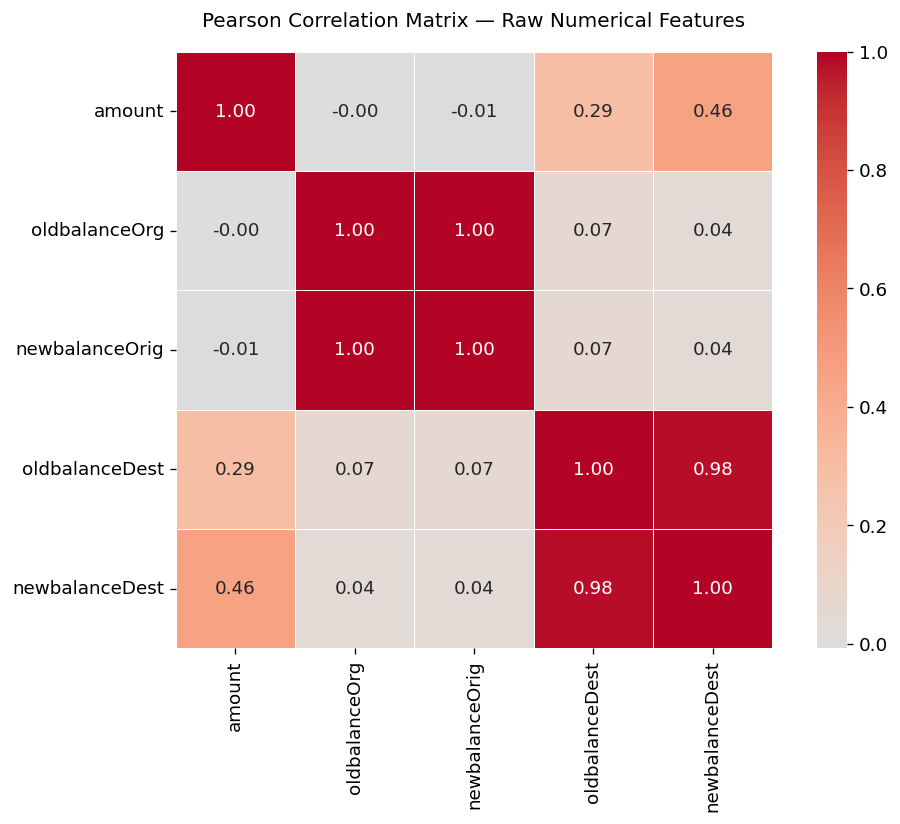

In [46]:
corr_mat = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Matrix — Raw Numerical Features', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

insight :

#### Entropy Analysis

In [47]:
print("\n=== ANALISIS ENTROPY (Feature Informativeness) ===")
cat_cols_entropy = ['type']
for col in cat_cols_entropy:
    probs = df[col].value_counts(normalize=True)
    ent = entropy(probs)
    max_ent = np.log(len(probs))
    print(f"\n[{col}]")
    print(f"  Shannon Entropy: {ent:.4f} nats")
    print(f"  Max Entropy (uniform): {max_ent:.4f} nats")
    print(f"  Normalized Entropy: {ent/max_ent:.4f}")
    print(f"  Interpretasi: {'High info content' if ent/max_ent > 0.7 else 'Skewed distribution'}")
    print(f"  Value Counts:\n{probs.round(4)}")

# Entropy untuk binned amount (sebagai preview Phase 3)
df_sample = df.sample(100000, random_state=42)
amount_binned = pd.qcut(df_sample['amount'], q=3, labels=['Low','Medium','High'], duplicates='drop')
probs_amount = amount_binned.value_counts(normalize=True)
ent_amount = entropy(probs_amount)
print(f"\n[amount (binned q=3)]")
print(f"  Shannon Entropy: {ent_amount:.4f} nats")
print(f"  Value Counts:\n{probs_amount.round(4)}")


=== ANALISIS ENTROPY (Feature Informativeness) ===

[type]
  Shannon Entropy: 1.3077 nats
  Max Entropy (uniform): 1.6094 nats
  Normalized Entropy: 0.8125
  Interpretasi: High info content
  Value Counts:
type
CASH_OUT    0.3517
PAYMENT     0.3381
CASH_IN     0.2199
TRANSFER    0.0838
DEBIT       0.0065
Name: proportion, dtype: float64

[amount (binned q=3)]
  Shannon Entropy: 1.0986 nats
  Value Counts:
amount
Low       0.3333
Medium    0.3333
High      0.3333
Name: proportion, dtype: float64


insight :

#### Temporal Analysis

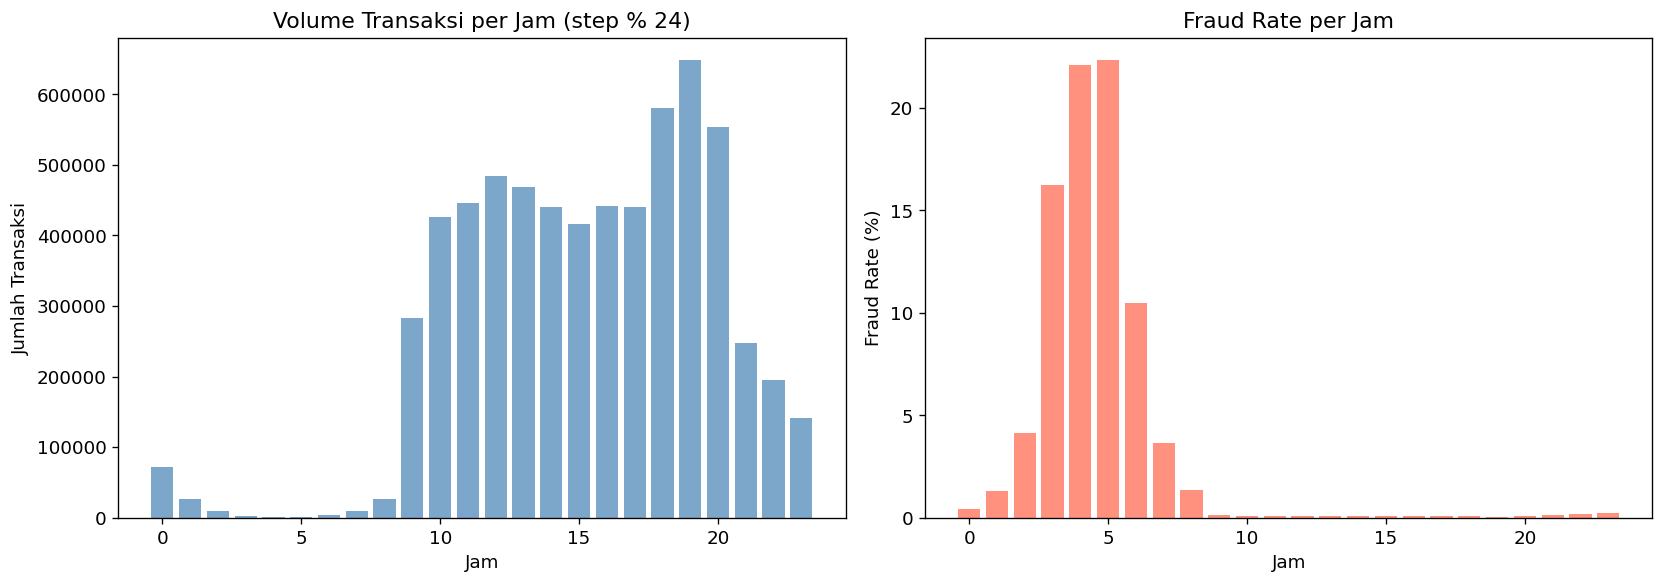

In [49]:
step_hourly = df.groupby(df['step'] % 24).agg(
    total=('isFraud', 'count'),
    fraud=('isFraud', 'sum')
).reset_index()
step_hourly.columns = ['hour', 'total', 'fraud']
step_hourly['fraud_rate'] = step_hourly['fraud'] / step_hourly['total']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(step_hourly['hour'], step_hourly['total'], color='steelblue', alpha=0.7)
axes[0].set_title('Volume Transaksi per Jam (step % 24)')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Jumlah Transaksi')
axes[1].bar(step_hourly['hour'], step_hourly['fraud_rate']*100, color='tomato', alpha=0.7)
axes[1].set_title('Fraud Rate per Jam')
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

Insight :